# Indicator Species Analysis in R

## Overview

Indicator species analysis identifies which species are characteristic of particular groups of sites (habitats, treatments, time periods). This answers a question that PERMANOVA cannot: *which specific species are driving the community differences?*

The **IndVal** (Indicator Value) approach (Dufrêne & Legendre 1997) measures indicator quality as:

```
IndVal = Specificity × Fidelity

Specificity (A): proportion of the species' occurrences that fall in the target group
Fidelity (B):    proportion of sites in the target group where the species occurs
```

Perfect indicator: A = 1 (only found in this group) and B = 1 (found at every site in this group).

The `indicspecies` package (`multipatt()`) extends this to combinations of groups, identifying species that indicate two or more groups simultaneously.

## Applications by Sector

| Sector | Example |
|---|---|
| **Ecology** | Which invertebrate taxa characterize reference vs. degraded sites? Which species are indicators of restored sites recovering toward reference condition? |
| **Healthcare** | Which microbial taxa are characteristic of disease state vs. healthy controls? |
| **Water quality** | Which taxa serve as bioindicators of pollution; which are sensitive vs. tolerant species? |

---

## Setup

In [1]:
library(tidyverse)
library(ggplot2)
library(vegan)
library(indicspecies)   # multipatt(), strassoc()

set.seed(42)

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'stringr' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'vegan' was built under R version 4.4.3"
Loading required package: permute

Warning message:
"package 'indi

## Data

We simulate a community matrix with species deliberately structured to be indicators of specific habitats — sensitive species (reference only), tolerant species (degraded only), generalists (all habitats), and recovering species (reference + restored).

In [2]:
n_sites <- 45; n_sp <- 30
habitat <- rep(c("reference", "degraded", "restored"), each = 15)

# Species groups with known indicator structure
# sp1-6:   sensitive — high in reference, absent in degraded
# sp7-12:  tolerant  — high in degraded, low in reference
# sp13-18: generalist — present in all habitats
# sp19-24: recovering — reference + restored
# sp25-30: rare/random

make_sp <- function(n_sites, probs_by_hab) {
  c(
    rbinom(15, 1, probs_by_hab[1]),
    rbinom(15, 1, probs_by_hab[2]),
    rbinom(15, 1, probs_by_hab[3])
  )
}

comm_mat <- cbind(
  replicate(6,  make_sp(n_sites, c(0.85, 0.05, 0.35))),  # sensitive
  replicate(6,  make_sp(n_sites, c(0.05, 0.85, 0.30))),  # tolerant
  replicate(6,  make_sp(n_sites, c(0.70, 0.65, 0.70))),  # generalist
  replicate(6,  make_sp(n_sites, c(0.80, 0.05, 0.75))),  # recovering
  replicate(6,  make_sp(n_sites, c(0.15, 0.15, 0.15)))   # rare/random
)
rownames(comm_mat) <- paste0("site", 1:n_sites)
colnames(comm_mat) <- c(
  paste0("sensitive",  1:6),
  paste0("tolerant",   1:6),
  paste0("generalist", 1:6),
  paste0("recovering", 1:6),
  paste0("rare",       1:6)
)

hab_factor <- factor(habitat, levels = c("reference", "degraded", "restored"))

cat(sprintf("Community matrix: %d sites × %d species\n",
            nrow(comm_mat), ncol(comm_mat)))
cat("Species groups: sensitive (1-6), tolerant (7-12), generalist (13-18),\n")
cat("                recovering (19-24), rare (25-30)\n")

Community matrix: 45 sites × 30 species
Species groups: sensitive (1-6), tolerant (7-12), generalist (13-18),
                recovering (19-24), rare (25-30)


---

## IndVal Analysis with `multipatt()`

In [3]:
# ── Run multipatt() ───────────────────────────────────────────────────────────
indval <- indicspecies::multipatt(
  comm_mat,
  cluster      = hab_factor,
  func         = "IndVal.g",  # IndVal.g: corrected for unequal group sizes
                               # IndVal:   original Dufrêne & Legendre (1997)
                               # r.g:      point-biserial correlation
  control      = how(nperm = 999)
)
summary(indval, indval.min = 0.25, alpha = 0.05)
# indval.min: only show species with IndVal >= threshold
# alpha: only show significant species (p < alpha)
# Output: for each species — which group(s) it indicates, IndVal, p-value


 Multilevel pattern analysis
 ---------------------------

 Association function: IndVal.g
 Significance level (alpha): 0.05

 Total number of species: 30
 Selected number of species: 18 
 Number of species associated to 1 group: 8 
 Number of species associated to 2 groups: 10 

 List of species associated to each combination: 

 Group reference  #sps.  3 
            stat p.value    
sensitive4 0.852   0.001 ***
sensitive2 0.800   0.001 ***
sensitive5 0.775   0.001 ***

 Group degraded  #sps.  5 
           stat p.value    
tolerant6 0.877   0.001 ***
tolerant1 0.852   0.001 ***
tolerant4 0.814   0.001 ***
tolerant2 0.808   0.001 ***
tolerant3 0.770   0.001 ***

 Group reference+restored  #sps.  9 
             stat p.value    
recovering4 0.931   0.001 ***
recovering1 0.876   0.001 ***
recovering2 0.876   0.001 ***
recovering6 0.876   0.001 ***
recovering5 0.856   0.001 ***
sensitive6  0.796   0.001 ***
recovering3 0.783   0.006 ** 
sensitive3  0.776   0.002 ** 
sensitive1  0.735  

### Extract and Tidy Results

In [4]:
# ── Tidy results table ────────────────────────────────────────────────────────
indval_df <- tibble(
  species = rownames(indval$sign),
  stat    = indval$sign$stat,           # IndVal statistic
  p_value = indval$sign$p.value
) %>%
  # Add which group(s) each species indicates
  bind_cols(
    as.data.frame(indval$sign[, 1:nlevels(hab_factor)])
  ) %>%
  rename(ref = s.reference, deg = s.degraded, rest = s.restored) %>%
  mutate(
    group = case_when(
      ref == 1 & deg == 0 & rest == 0 ~ "reference only",
      ref == 0 & deg == 1 & rest == 0 ~ "degraded only",
      ref == 0 & deg == 0 & rest == 1 ~ "restored only",
      ref == 1 & deg == 0 & rest == 1 ~ "reference + restored",
      TRUE ~ "multi-group"
    ),
    p_adj = p.adjust(p_value, method = "BH")
  ) %>%
  filter(p_adj < 0.05) %>%
  arrange(group, desc(stat))

print(indval_df)

# ── Count indicators by habitat ───────────────────────────────────────────────
indval_df %>%
  count(group) %>%
  arrange(desc(n))

# A tibble: 18 × 8
   species      stat p_value   ref   deg  rest group                  p_adj
   <chr>       <dbl>   <dbl> <dbl> <dbl> <dbl> <chr>                  <dbl>
 1 tolerant6   0.877   0.001     0     1     0 degraded only        0.0015 
 2 tolerant1   0.852   0.001     0     1     0 degraded only        0.0015 
 3 tolerant4   0.814   0.001     0     1     0 degraded only        0.0015 
 4 tolerant2   0.808   0.001     0     1     0 degraded only        0.0015 
 5 tolerant3   0.770   0.001     0     1     0 degraded only        0.0015 
 6 tolerant5   0.730   0.002     0     1     1 multi-group          0.00262
 7 recovering4 0.931   0.001     1     0     1 reference + restored 0.0015 
 8 recovering1 0.876   0.001     1     0     1 reference + restored 0.0015 
 9 recovering2 0.876   0.001     1     0     1 reference + restored 0.0015 
10 recovering6 0.876   0.001     1     0     1 reference + restored 0.0015 
11 recovering5 0.856   0.001     1     0     1 reference + restored 0

group,n
<chr>,<int>
reference + restored,9
degraded only,5
reference only,3
multi-group,1


---

## Specificity and Fidelity Components

Decomposing IndVal into its A (specificity) and B (fidelity) components reveals different indicator strategies.

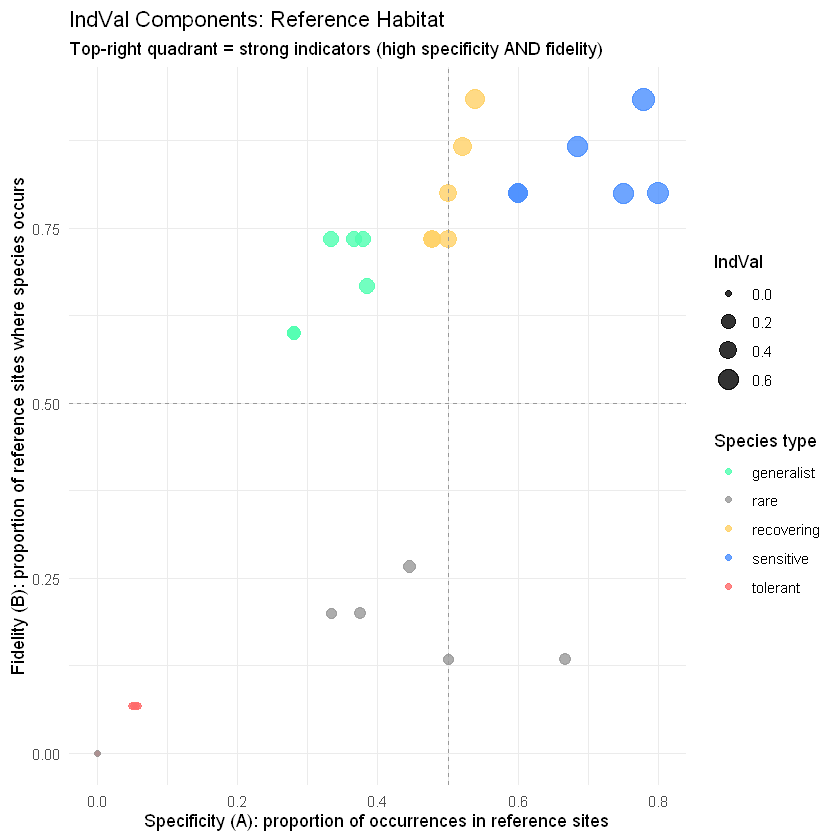

In [5]:
# ── Compute A (specificity) and B (fidelity) for each species/group ───────────
ab_vals <- indicspecies::strassoc(
  comm_mat,
  cluster = hab_factor,
  func    = "A.g"   # specificity
)
b_vals  <- indicspecies::strassoc(
  comm_mat,
  cluster = hab_factor,
  func    = "B"     # fidelity
)

# ── A-B plot for reference habitat ───────────────────────────────────────────
ab_df <- tibble(
  species     = rownames(ab_vals),
  specificity = ab_vals[, "reference"],
  fidelity    = b_vals[,  "reference"],
  indval      = specificity * fidelity,
  sp_type     = case_when(
    str_starts(species, "sensitive")  ~ "sensitive",
    str_starts(species, "tolerant")   ~ "tolerant",
    str_starts(species, "generalist") ~ "generalist",
    str_starts(species, "recovering") ~ "recovering",
    TRUE                              ~ "rare"
  )
)

ggplot(ab_df, aes(x = specificity, y = fidelity,
                  color = sp_type, size = indval)) +
  geom_point(alpha = 0.8) +
  geom_hline(yintercept = 0.5, linetype = "dashed", color = "gray60") +
  geom_vline(xintercept = 0.5, linetype = "dashed", color = "gray60") +
  scale_color_manual(
    values = c(sensitive  = "#4a8fff", tolerant   = "#ff6b6b",
               generalist = "#4fffb0", recovering = "#ffd166",
               rare       = "gray60")
  ) +
  scale_size_continuous(range = c(1.5, 6)) +
  labs(
    title = "IndVal Components: Reference Habitat",
    subtitle = "Top-right quadrant = strong indicators (high specificity AND fidelity)",
    x = "Specificity (A): proportion of occurrences in reference sites",
    y = "Fidelity (B): proportion of reference sites where species occurs",
    color = "Species type", size = "IndVal"
  ) +
  theme_minimal()

---

## Visualization: Indicator Species Summary

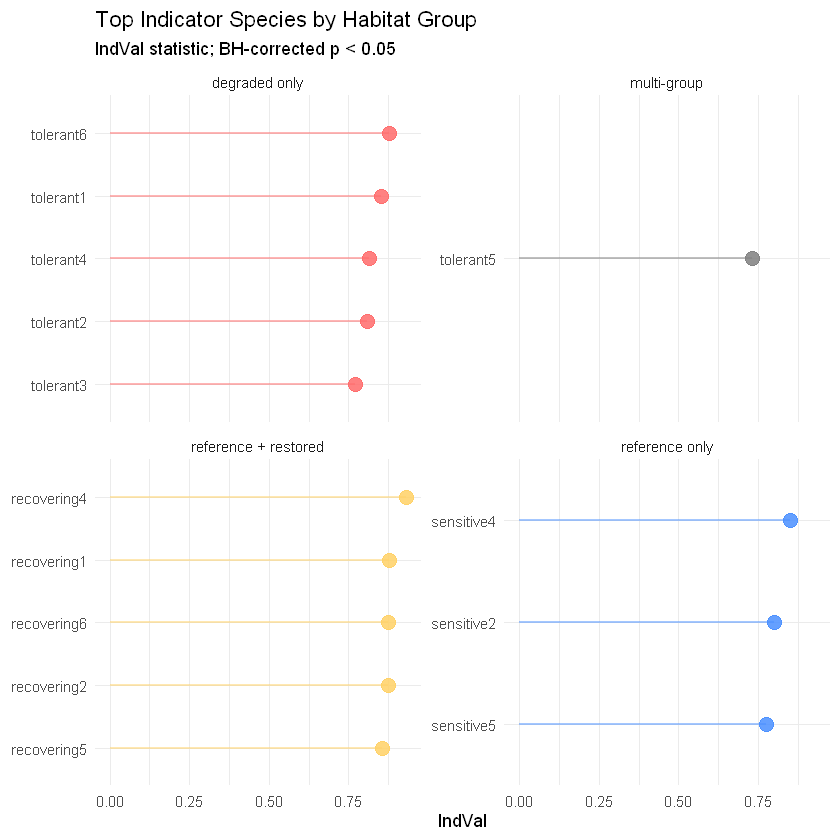

In [6]:
# ── Dot plot of top indicators per habitat ────────────────────────────────────
top_indicators <- indval_df %>%
  group_by(group) %>%
  slice_max(stat, n = 5) %>%
  ungroup()

ggplot(top_indicators,
       aes(x = stat, y = reorder(species, stat), color = group)) +
  geom_point(size = 4, alpha = 0.85) +
  geom_segment(aes(x = 0, xend = stat,
                   y = reorder(species, stat),
                   yend = reorder(species, stat)),
               linewidth = 0.8, alpha = 0.5) +
  facet_wrap(~ group, scales = "free_y") +
  scale_color_manual(
    values = c("reference only"      = "#4a8fff",
               "degraded only"       = "#ff6b6b",
               "restored only"       = "#aaffcc",
               "reference + restored" = "#ffd166")
  ) +
  labs(
    title = "Top Indicator Species by Habitat Group",
    subtitle = "IndVal statistic; BH-corrected p < 0.05",
    x = "IndVal", y = NULL
  ) +
  theme_minimal() +
  theme(legend.position = "none")

---

## Reporting Results

In [7]:
# ── Summary table ─────────────────────────────────────────────────────────────
indval_df %>%
  select(species, group, stat, p_adj) %>%
  mutate(across(where(is.numeric), ~round(.x, 3)))

# Standard reporting format:
# "Indicator species analysis (IndVal.g; Dufrêne & Legendre 1997;
#  indicspecies package, De Cáceres & Legendre 2009) identified XX species
#  as significant indicators of specific habitat types (BH-corrected p < 0.05;
#  999 permutations). Reference sites were characterized by XX sensitive
#  taxa (e.g., [species]: IndVal = X.XX, p_adj = .XXX), which showed high
#  specificity to reference conditions. Degraded sites were indicated by XX
#  pollution-tolerant taxa (e.g., [species]: IndVal = X.XX). Notably,
#  XX species indicated both reference and restored sites (IndVal range:
#  X.XX–X.XX), suggesting partial community recovery in restored sites."
#
# Cite: De Cáceres M & Legendre P (2009) Associations between species
# and groups of sites. Ecology 90:3566-3574.

species,group,stat,p_adj
<chr>,<chr>,<dbl>,<dbl>
tolerant6,degraded only,0.877,0.002
tolerant1,degraded only,0.852,0.002
tolerant4,degraded only,0.814,0.002
tolerant2,degraded only,0.808,0.002
tolerant3,degraded only,0.770,0.002
tolerant5,multi-group,0.730,0.003
recovering4,reference + restored,0.931,0.002
recovering1,reference + restored,0.876,0.002
recovering2,reference + restored,0.876,0.002


---

## Common Pitfalls

**1. Using the original `IndVal` without group size correction**  
When groups have unequal numbers of sites, the original IndVal is biased toward larger groups. Always use `func = "IndVal.g"` which corrects for unequal group sizes.

**2. Not correcting for multiple comparisons**  
With many species, the chance of false positives is high. Always apply BH correction to the p-values returned by `multipatt()`. The raw p-values alone should not be used.

**3. Over-interpreting weak indicators**  
An IndVal of 0.30 with p < 0.05 is statistically significant but ecologically weak — the species is not a reliable indicator in practice. Use a minimum IndVal threshold (e.g., ≥ 0.5 or ≥ 0.6) for species to be considered practically meaningful indicators.

**4. Using indicator species analysis as a substitute for community-level tests**  
IndVal identifies which species characterize groups — it does not test whether groups differ significantly in overall composition. Always run PERMANOVA first, then use IndVal to identify the driving species.

**5. Ignoring multi-group indicators**  
`multipatt()` tests all combinations of groups. A species indicating "reference + restored" is ecologically informative — it suggests that species is sensitive to degradation and has recovered. Do not discard these multi-group results.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*